# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from fontTools.ttLib.tables._p_r_e_p import table__p_r_e_p

from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
from dependencies.bopdftprojections.bopdftprojections.projections import Projections
from Tools.DatasetTools.DatasetOperator import  Dataset
from Tools.DatasetTools.Tools import  Plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
target_case = 'EF_nmhcp'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
from Tools.DatasetTools.MLConveniences import filter_features

In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)

In [3]:
DS = Dataset(dataset=dataset, target_name=target_case, load_features_only = ['0.7dProjections 0.5OS BOP', 'ACE', 'SOAP_specific_small', 'dataset'])
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]

In [4]:
P = Plotting()

In [5]:
CHULL = {}
for phase, bs_phase in BS.groupby(by='Phase'):
    if phase == 'R':
        continue
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))

In [6]:
train_features = DS.Features

# LOAD MODELS 

In [7]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [8]:
voting_regressor = joblib.load(regressor_file)

# Prediction for the learning dataset

In [9]:
ModelName = 'Kernel Ridge'
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE' }

In [10]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small')])

In [11]:
modelname = 'Kernel Ridge'

In [12]:
predictionBS = DS.BS.copy()

In [13]:
DS.target_name

'EF_nmhcp'

In [66]:
Err = {}

In [67]:
plt.rcParams['figure.figsize']

[7.0, 5.0]

In [ ]:
targ

In [80]:
np.sqrt((Err[combi]**2).sum()/len(Err[combi]))

69.16509995534

In [81]:
from sklearn.metrics import r2_score

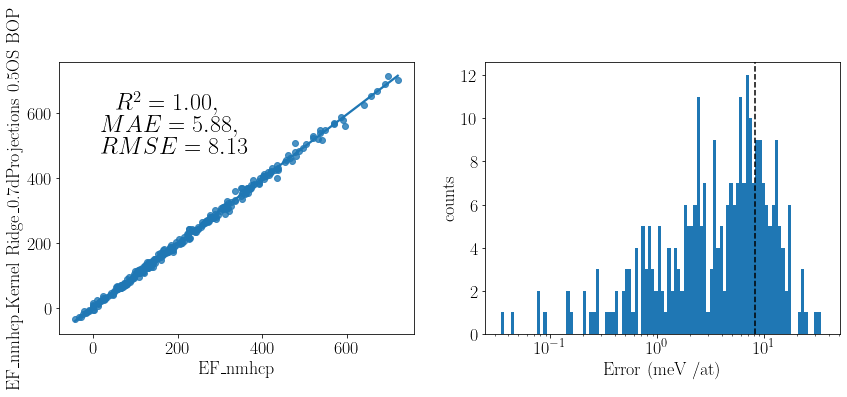

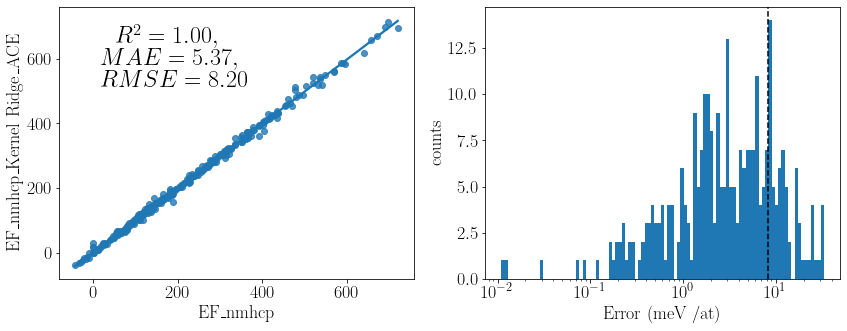

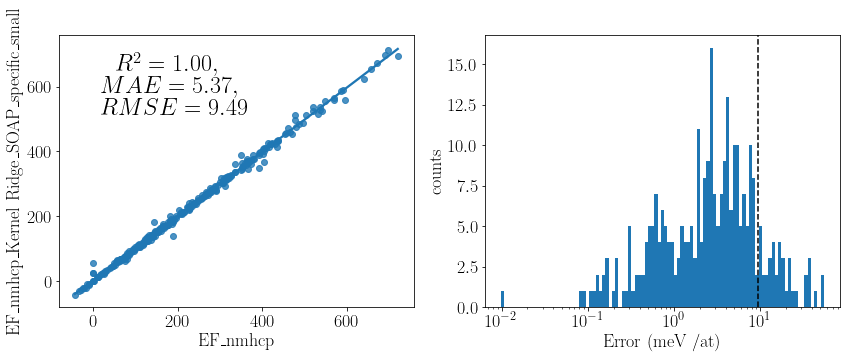

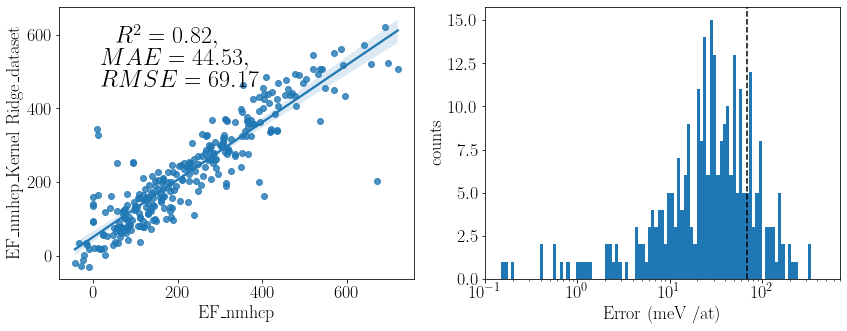

In [95]:
for featurenames, feature in DS.Features.items():
    prediction_name = f'{DS.target_name}_{ modelname }_{featurenames}'
    combi = (modelname, featurenames)
    voting_regressor[combi].fit(feature, DS.BS[DS.target_name])
    predictionBS[prediction_name] = voting_regressor[combi].predict(feature)
    Err[combi] =(  predictionBS[prediction_name] - predictionBS[DS.target_name] ).abs()*1000
    rmse=np.sqrt((Err[combi]**2).sum()/len(Err[combi]))
    r2 = r2_score(DS.BS[target_case], predictionBS[prediction_name])
    mae =  Err[combi].mean()
    fig, ax = plt.subplots(1,2, figsize= [ plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1] ]  )
    log_bins = np.logspace(np.log10(Err[combi].min()), np.log10(Err[combi].max()), 100 )
    log_bins = np.logspace(np.log10(Err[combi].min()), np.log10(Err[combi].max()), 100 )
    sns.regplot(x=DS.BS[target_case]*1000, y = predictionBS[prediction_name]*1000, ax = ax[0])
    ax[1].hist(Err[combi], bins=log_bins)
    ax[1].axvline(rmse,ls='--',c='k')
    ax[1].annotate(rf'$R^2 = {r2:.2f},\\ MAE={mae:.2f},\\ RMSE={rmse:.2f}$', (0.1, 0.8), xycoords='figure fraction' )
    ax[1].set_xscale('log')
    ax[1].set_ylabel ('counts')
    ax[1].set_xlabel('Error (meV /at)')
#    sns.histplot(x=E[combi], bins=log_bins, log_scale='x', ax = ax[1])

In [20]:
for keys, E in E.items():
    break

In [31]:
predicted_targets = predictionBS.filter(regex=ModelName).columns

In [32]:
predicted_targets

Index(['EF_nmhcp_Kernel Ridge_0.7dProjections 0.5OS BOP',
       'EF_nmhcp_Kernel Ridge_ACE',
       'EF_nmhcp_Kernel Ridge_SOAP_specific_small',
       'EF_nmhcp_Kernel Ridge_dataset'],
      dtype='object')

In [47]:
PREDICT_CHULL = {}
phase_predictionBS = {}
for phase, predict_bs_phase in predictionBS.groupby(by='Phase'):
    if phase == 'R':
        continue
    phase_predictionBS[phase] = predict_bs_phase

In [48]:
for predicted_target in predicted_targets:
    PREDICT_CHULL[predicted_target] = {}
    for phase, predict_bs_phase in phase_predictionBS.items():
        PREDICT_CHULL[predicted_target].update(
            P.get_convex_hulls({phase: predict_bs_phase}, ['Fe', 'Mo'],getproperty=predicted_target)
        )

In [51]:
CHULL

{'A15': <scipy.spatial._qhull.ConvexHull at 0x7f6417da23d0>,
 'C14': <scipy.spatial._qhull.ConvexHull at 0x7f6417cd31f0>,
 'C15': <scipy.spatial._qhull.ConvexHull at 0x7f6417d06ee0>,
 'C36': <scipy.spatial._qhull.ConvexHull at 0x7f6417cd3ac0>,
 'bcc': <scipy.spatial._qhull.ConvexHull at 0x7f6389949b80>,
 'chi': <scipy.spatial._qhull.ConvexHull at 0x7f6417da2430>,
 'fcc': <scipy.spatial._qhull.ConvexHull at 0x7f6389949c40>,
 'hcp': <scipy.spatial._qhull.ConvexHull at 0x7f6417f64280>,
 'mu': <scipy.spatial._qhull.ConvexHull at 0x7f6389949dc0>,
 'sigma': <scipy.spatial._qhull.ConvexHull at 0x7f6417da29d0>}

In [61]:
len(predicted_targets)

4

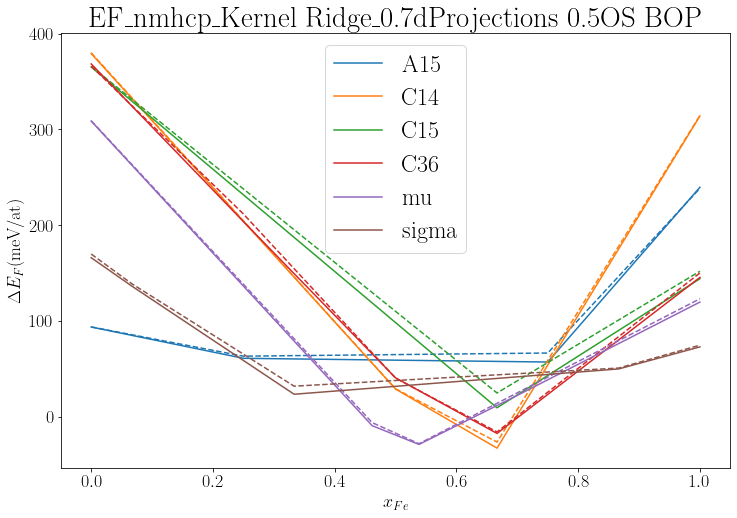

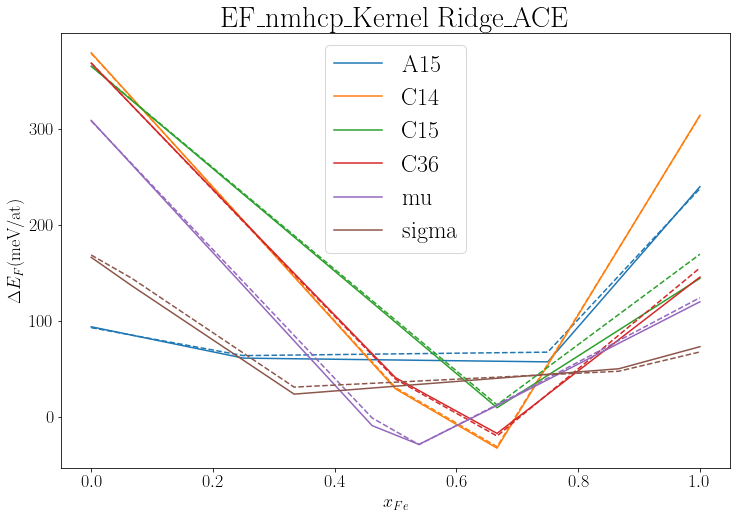

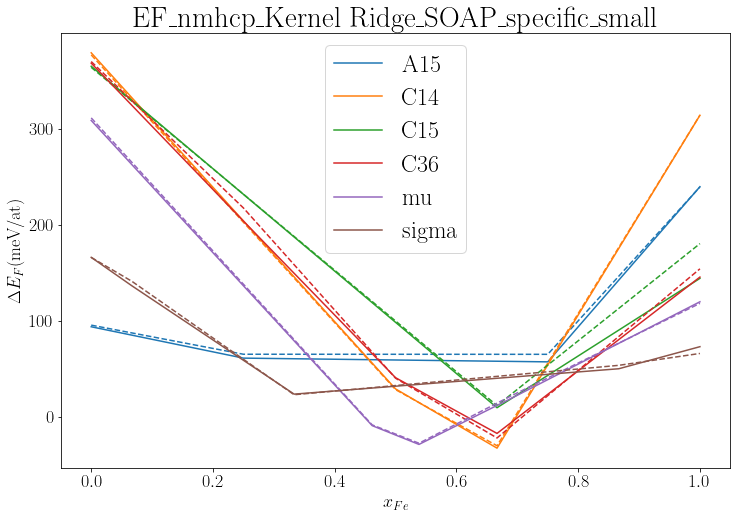

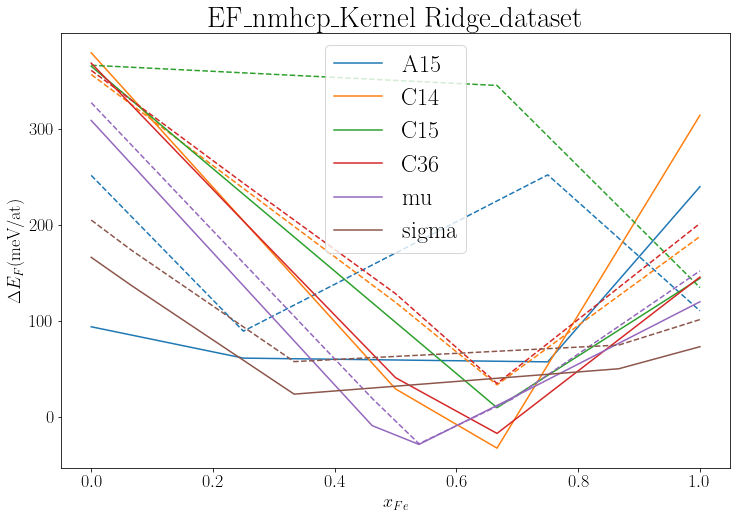

In [65]:
for predicted_target in predicted_targets:
    fig, ax = plt.subplots(figsize=(12,8))
    for phase, chull in CHULL.items():
        if phase == 'bcc':
            continue
        if phase == 'fcc':
            continue
        if phase == 'hcp':
            continue
        if phase == 'chi':
            continue
        if phase == 'R':
            continue
        bs_phase = BS[BS.Phase == phase]
        prediction_phase_bs = phase_predictionBS[phase]
        vertices = np.unique( chull.simplices[chull.good])
        chull_prediction = PREDICT_CHULL[predicted_target][phase]
        prediction_vertices = np.unique(chull_prediction.vertices[chull_prediction.good])
        xy= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
        xy_prediction = prediction_phase_bs.iloc[vertices][['Fe_pv', predicted_target]].sort_values(by='Fe_pv')
        l=ax.plot(xy['Fe_pv'].values, xy[target_case].values*1000, label = phase)
        ax.plot(xy_prediction['Fe_pv'].values, xy_prediction[predicted_target].values*1000, '--', color=l[0].get_color())
    ax.legend()
    ax.set_title(predicted_target)
    ax.set_xlabel(r'$x_{Fe}$')
    ax.set_ylabel(r'$\Delta E_F $(meV/at)')

In [50]:
PREDICT_CHULL[predicted_targets[0]]

{'A15': <scipy.spatial._qhull.ConvexHull at 0x7f63743e97c0>,
 'C14': <scipy.spatial._qhull.ConvexHull at 0x7f6374bce760>,
 'C15': <scipy.spatial._qhull.ConvexHull at 0x7f63743e9070>,
 'C36': <scipy.spatial._qhull.ConvexHull at 0x7f63743e9ac0>,
 'bcc': <scipy.spatial._qhull.ConvexHull at 0x7f637423be50>,
 'chi': <scipy.spatial._qhull.ConvexHull at 0x7f637423b6d0>,
 'fcc': <scipy.spatial._qhull.ConvexHull at 0x7f637423b5e0>,
 'hcp': <scipy.spatial._qhull.ConvexHull at 0x7f637423b0a0>,
 'mu': <scipy.spatial._qhull.ConvexHull at 0x7f637423b280>,
 'sigma': <scipy.spatial._qhull.ConvexHull at 0x7f6374264190>}

In [58]:
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
for (modelkey, modelparam, phase), featurecnav in featurescnav.items():
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION_{phase}_{modelkey}_{modelparam}.csv')
    print(modelkey, modelparam, phase, featurenames[modelkey])
    combi = (ModelName, featurenames[modelkey])
    Prediction_Values[modelkey, phase] = pd.Series(voting_regressor[combi].predict(featurecnav), index=featurecnav.index, name=f'{target_case}__{modelkey}').to_frame()
    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
#        this_prediction = pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#        bag_of_predictions[combi].append(this_prediction)
        Prediction_Values[modelkey, phase][f'vote_{i}']  =pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#    bag_of_predictions[combi] = pd.DataFrame(bag_of_predictions[combi]).transpose()
    Prediction_Values[modelkey, phase]['std_votes'] = Prediction_Values[modelkey, phase].filter(regex='vote_[0-9]+').std(axis=1)#bag_of_predictions[combi].std(axis=1)
    Prediction_Values[modelkey, phase].to_csv(prediction_values_location)

0.7dprojections_0.5os 16 R 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os 16 R_old 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os 16 P 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os 16 delta 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os 16 M 0.7dProjections 0.5OS BOP
ACE lmax=321 R ACE
ACE lmax=321 R_old ACE
ACE lmax=321 P ACE
ACE lmax=321 delta ACE
ACE lmax=321 M ACE


In [59]:
Prediction_Values[modelkey, phase].columns

Index(['EF_nmhcp__ACE', 'vote_0', 'vote_1', 'vote_2', 'vote_3', 'vote_4',
       'vote_5', 'vote_6', 'vote_7', 'vote_8', 'vote_9', 'vote_10', 'vote_11',
       'std_votes'],
      dtype='object')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

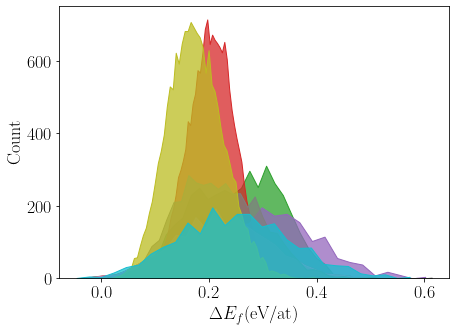

In [60]:
fig, ax = plt.subplots()
for key, serie in Prediction_Values.items():
    sns.histplot(Prediction_Values[key][f'{target_case}__{key[0]}'], element='poly', ax = ax)
ax.set_xlabel(r'$\Delta E_f $(eV/at)')

In [61]:
select_model = '0.7dprojections_0.5os'

In [62]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [69]:
Prediction_Values[('0.7dprojections_0.5os', 'R')]

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,std_votes
Fe_pv53.R.NM,0.166247,0.166797,0.165478,0.166433,0.166791,0.165638,0.165541,0.165962,0.166406,0.167361,0.165913,0.166397,0.000598
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.080852,0.081219,0.080986,0.078216,0.078585,0.082450,0.078202,0.082371,0.082613,0.084710,0.078863,0.081161,0.002148
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.140738,0.137314,0.147420,0.139263,0.141152,0.140872,0.139197,0.140928,0.138885,0.140323,0.141599,0.141169,0.002563
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.064664,0.065791,0.061989,0.067297,0.067038,0.054890,0.063816,0.065320,0.065289,0.069141,0.065458,0.065277,0.003730
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.133411,0.132431,0.134632,0.124947,0.121656,0.113693,0.113526,0.145527,0.128291,0.166568,0.148185,0.138062,0.015839
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.343387,0.380013,0.342184,0.311590,0.361334,0.414650,0.219288,0.341832,0.347128,0.365004,0.352944,0.341287,0.048718
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.446977,0.452699,0.440158,0.432813,0.449008,0.450909,0.448750,0.451994,0.452048,0.449204,0.448909,0.440258,0.006382
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.350453,0.341987,0.356628,0.344071,0.354823,0.348845,0.360452,0.349332,0.353578,0.351297,0.349687,0.344281,0.005680
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.409366,0.417125,0.409694,0.390899,0.413563,0.415167,0.406069,0.408466,0.416346,0.410443,0.411854,0.403395,0.007457


In [70]:
from sklearn.metrics import r2_score, mean_squared_error

In [71]:
from scipy.stats import pearsonr, linregress

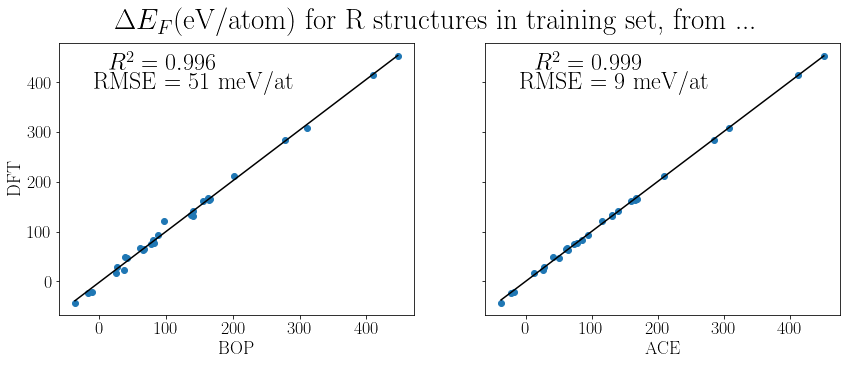

In [72]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE'}
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x))
    ax.scatter(x, y) 
    ax.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    ax.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    ax.set_xlabel(featurename_label[featuregroup])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig('Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT.pdf')

In [73]:
reg

array([ 1.00403544, -0.27943196])

In [74]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem,Structure
Mo_sv56.P-BBBBBBBBBBBB.NM,56,0.0,56.0,0.0,1.0,0,1,11


In [75]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M')])

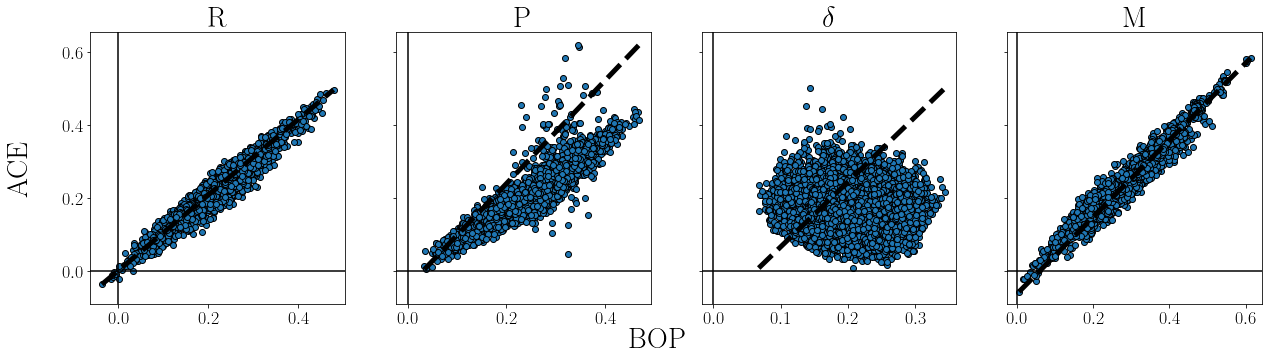

In [76]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, ax  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Prediction_Values[(bopmodel, phase)].index.intersection(Prediction_Values[(acemodel, phase)].index)
    x = Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    ax.scatter(x,y,edgecolor='k')
    ax.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    ax.set_title(phase_label[phase])
    ax.axhline(c='k')
    ax.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig('Fe-Mo/graphs/Fe-Mo-PredictionDifferences.pdf')

# predicted vs DFT

# Predicted convex hulls 

In [98]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls

In [79]:
from scipy.spatial import ConvexHull

In [77]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [78]:
BS_predict.keys()#['R'].filter(regex=target_case)

dict_keys(['R', 'R_old', 'P', 'delta', 'M'])

In [80]:
phasesloc= {'R':0, 'P': 1,'delta':2 ,'M':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex='EF_nmhcp').columns)}

In [81]:
targetsloc

{'EF_nmhcp__0.7dprojections_0.5os': 0, 'EF_nmhcp__ACE': 1}

In [82]:
from matplotlib.lines import Line2D

In [83]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M')])

In [84]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE'}

In [85]:
phase_labels = {'delta': r'$\delta$', 'R': 'R', 'M': 'M', 'P': 'P'}

In [86]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}
fig, axes = plt.subplots(len(targetsloc), len(phasesloc), sharey = True, sharex=True, figsize =(15,8))
for target_name, J in targetsloc.items(): #(target_name, targetvalues), ax in zip(bspredict.filter(regex=target_case).items(), axes):
    if 'R_old' in phase:
        continue
#    if 'P' not in phase:
#        continue
#    fig, axes = plt.subplots(1,2, sharey=True)
    labels = []
    handles = []
    CHULLS[target_name]={}
    featurename = target_name.replace(target_case+'__', '')
    axes[J, 0].set_ylabel(feature_labels[featurename])
    for phase, I in phasesloc.items(): # phase, bspredict in BS_predict.items():
        axes[0,I].set_title(phase_labels[phase])
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name ])
        axes[J,I].scatter(plottable['Fe_pv'].values, plottable[target_name].values, c='k')
        chull_xy = pd.DataFrame([])
        chull = P.get_convex_hulls(
            {phase: plottable }, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0,-10 )
        )
        CHULLS[target_name].update(chull)
        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        all_vertices_high= np.unique(np.hstack(chull[phase].simplices[~chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')
        opo_chull[(phase, target_name)] = plottable.iloc[all_vertices_high].sort_values(by='Fe_pv')
        l = axes[J,I].plot(inchull[(phase, target_name)]['Fe_pv'].values, inchull[(phase, target_name)][target_name].values, 'o-', label = 'chull')
        labels.append(target_name)
        handles.append(l[0])
#        axes[J,I].plot(opo_chull[(phase, target_name)]['Fe_pv'].values, opo_chull[(phase, target_name)][target_name].values, 'o-', c=l[0].get_color(), label = target_name)
#        axes[J,I].plot(opo_chull[(phase, target_name)]['Fe_pv'].values, opo_chull[(phase, target_name)][target_name].values, 'o-', c='r', label = 'opo_chull')
        axes[J,I].axhline(c='k')
#        ax.legend(handles, labels)
handles = [
    Line2D([0], [0], marker = 'o', markerfacecolor='k'),
    Line2D([0], [0], marker = 'o', linestyle='-', color='b',  markerfacecolor='b', markeredgecolor='b'),
    Line2D([0], [0], marker = 'o', markerfacecolor='r', linestyle='-', color='r'),
]
fig.supylabel(r'$\Delta E_F$ (meV/atom)')#target_name)
labels = ['predictions', 'chull', 'oppo_chull']
fig.supxlabel('$x_{Fe}$')
#fig.legend(handles, labels, bbox_to_anchor=(1.1, 1))
fig.savefig('Fe-Mo/graphs/compare_predictions.pdf')

NameError: name 'Plotting' is not defined

In [ ]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010}
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
r_training_samples = BS.index.str.contains('R')
#for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
for featuregroup, I in featurename_pos.items():
    fig = plt.figure(figsize=(plt.rcParams['figure.figsize'][0]*1.5,plt.rcParams['figure.figsize'][1])) #, ax = plt.subplots()
    ax = fig.add_axes([0.1, 0.15, 0.5, 0.75])
    targetname = f'{target_case}__{featuregroup}'
    this_chull = inchull[('R', targetname)].index
    ax.scatter(BS_predict['R']['Fe_pv'], Prediction_Values[(featuregroup, 'R')][targetname]*1000, label = 'Predictions', edgecolor='w')
    ax.plot(
        BS_predict['R']['Fe_pv'][this_chull].values,
        Prediction_Values[(featuregroup, 'R')][targetname][this_chull].values*1000, 
        'k',
        label = 'convex hull'
    )
    ax.fill_between(
        BS_predict['R']['Fe_pv'][this_chull].values,
        Prediction_Values[(featuregroup, 'R')][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
        Prediction_Values[(featuregroup, 'R')][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
        label = 'test error',
        alpha=0.5
    )
    ax.errorbar(
        BS_predict['R']['Fe_pv'][this_chull].values,
        Prediction_Values[(featuregroup, 'R')][targetname][this_chull].values*1000, 
        yerr= Prediction_Values[(featuregroup, 'R')]['std_votes'][this_chull].values*1000,
        fmt='.k',
        lolims=True,
        label = 'std from bag of predictions'
    )
    ax.scatter(
        BS['Fe_pv'][r_training_samples],
        BS[target_case][r_training_samples]*1000,
        edgecolor='k',
        label='DFT calculations',
        s = 100
    )
    targetname = f'{target_case}__{featuregroup}'
    ax.set_title(ModelName+' / '+featurename_label[featuregroup])
    ax.set_xlabel('$x_{Fe}$')
    ax.set_ylabel(r'$\Delta E_F$ (meV / atom)')
    ax.legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [86]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [87]:
from scipy.spatial import Delaunay

In [88]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [89]:
import pdb

In [90]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [91]:
targetname

'EF_nmhcp__ACE'

In [92]:
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

0.0

In [93]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [94]:
distances_to_chull = pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)

In [95]:
selection = xy.index.str.contains('NM')

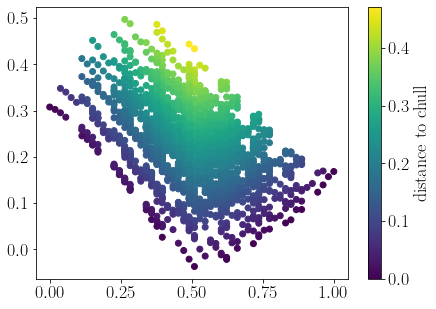

In [96]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

In [97]:
selection.sum()

2048

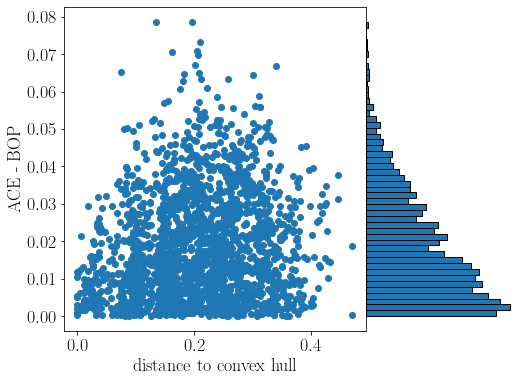

In [98]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = ax)
ax2.set_axis_off()
ax.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
ax.set_xlabel ('distance to convex hull')
ax.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

Text(0.5, 1.0, 'Kernel Ridge / EF_nmhcp__ACE')

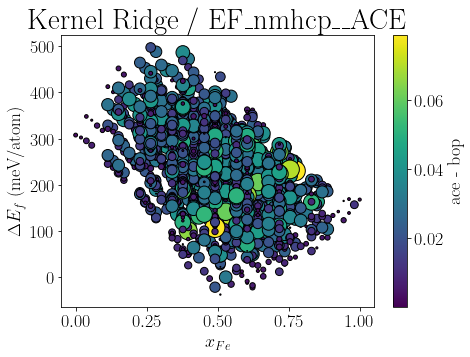

In [99]:
fig, ax = plt.subplots()
mapble = ax.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (meV/atom)')
ax.set_title(ModelName+' / '+targetname)

In [102]:
sbop, pbop = pearsonr(Prediction_Values[('0.7dprojections_0.5os', 'R')]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop], Prediction_Values[('ACE', 'R')]['EF_nmhcp__ACE'][inchull_bop])
sace, pace = pearsonr(Prediction_Values[('0.7dprojections_0.5os', 'R')]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], Prediction_Values[('ACE', 'R')]['EF_nmhcp__ACE'][inchull_ace])

In [107]:
inchull_bop

Index(['Mo_sv53.R.NM', 'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAABAABB.NM', 'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv53.R.NM'],
      dtype='object')

In [108]:
Prediction_Values[('0.7dprojections_0.5os', 'R')]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop]

Mo_sv53.R.NM                       0.310538
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.054258
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM   -0.036762
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM   -0.016643
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.023022
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM     0.064664
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM     0.080852
Fe_pv53.R.NM                       0.166247
Name: EF_nmhcp__0.7dprojections_0.5os, dtype: float64

In [110]:
Prediction_Values[('ACE', 'R')]['EF_nmhcp__ACE'][inchull_bop]#, label = f'BOP, $R^2 = {sbop:.3f}$'

Mo_sv53.R.NM                       0.307519
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.064302
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM   -0.037121
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM   -0.021774
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.031339
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM     0.063725
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM     0.086085
Fe_pv53.R.NM                       0.168144
Name: EF_nmhcp__ACE, dtype: float64

In [125]:
Phases = {'R':'R', 'delta': r'$\delta$', 'P': 'P', 'M':'M'}

In [127]:
Phases

{'R': 'R', 'delta': '$\\delta$', 'P': 'P', 'M': 'M'}

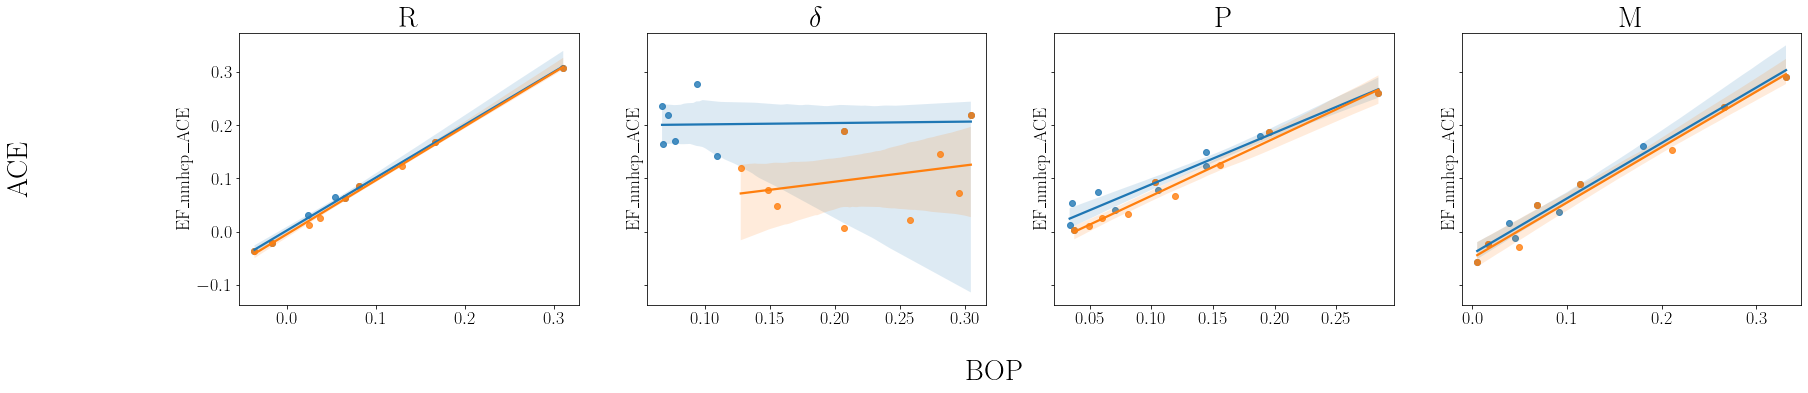

In [143]:
fig, axes = plt.subplots(1, len(Phases), sharey=True, figsize=(plt.rcParams['figure.figsize'][0]*len(Phases), plt.rcParams['figure.figsize'][1]))
for (phase, title), ax  in zip(Phases.items(), axes):
    inchull_bop = inchull[(phase, 'EF_nmhcp__0.7dprojections_0.5os')].index
    inchull_ace = inchull[(phase, 'EF_nmhcp__ACE')].index
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop]
        , y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop], label = f'BOP, $R^2 = {sbop:.3f}$',
        ax=ax
    )
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], 
        y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace], label = f'ACE, $R^2 = {sace:.3f}$', ax = ax, 
    )
    ax.set_xlabel('')
    ax.set_title(title)
fig.supxlabel ('BOP', y=-0.1)
fig.supylabel ('ACE', x=0.01)
plt.savefig(f'{dataset}/graphs/samples_in_convex_hull.pdf')

# Recover samples in convex hull for validation 

In [91]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [92]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)

In [93]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, 'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [94]:
inchull[('R','EF_nmhcp__0.7dprojections_0.5os' )].shape

(8, 3)

In [95]:
    AtomsObjects[phase]['atoms'][inchullist.index]

Mo_sv52.M-BBBBBBBBBBB.NM           (Atom('Mo', [0.687132056460881, 1.275763155206...
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM     (Atom('Mo', [0.682491389302961, 1.267147064427...
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM     (Atom('Mo', [0.6777867396928076, 1.25841218068...
Fe_pv16Mo_sv36.M-BBBBBBBAAAA.NM    (Atom('Mo', [0.6681763553306703, 1.24056906863...
Fe_pv20Mo_sv32.M-BBBBBBAAAAA.NM    (Atom('Mo', [0.6632657172807414, 1.23145173662...
Fe_pv24Mo_sv28.M-BBBBBAAAAAA.NM    (Atom('Mo', [0.6582812681260509, 1.22219736328...
Fe_pv28Mo_sv24.M-ABBBBAAAAAA.NM    (Atom('Fe', [0.6532201701111321, 1.21280067991...
Fe_pv52.M-AAAAAAAAAAA.NM           (Atom('Fe', [0.6210603654963448, 1.15309120569...
Name: atoms, dtype: object

In [96]:
AtomsObjects[phase]['atoms'][opo_chull[(phase, target_name)].index]

Mo_sv52.M-BBBBBBBBBBB.NM           (Atom('Mo', [0.687132056460881, 1.275763155206...
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM     (Atom('Mo', [0.682491389302961, 1.267147064427...
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM     (Atom('Mo', [0.6777867396928076, 1.25841218068...
Fe_pv16Mo_sv36.M-BBBBBBBAAAA.NM    (Atom('Mo', [0.6681763553306703, 1.24056906863...
Fe_pv20Mo_sv32.M-BBBBBBAAAAA.NM    (Atom('Mo', [0.6632657172807414, 1.23145173662...
Fe_pv24Mo_sv28.M-BBBBBAAAAAA.NM    (Atom('Mo', [0.6582812681260509, 1.22219736328...
Fe_pv28Mo_sv24.M-ABBBBAAAAAA.NM    (Atom('Fe', [0.6532201701111321, 1.21280067991...
Fe_pv52.M-AAAAAAAAAAA.NM           (Atom('Fe', [0.6210603654963448, 1.15309120569...
Name: atoms, dtype: object

In [97]:
#fig, axes = plt.subplots(1, len(Prediction_Values), figsize = (plt.rcParams['figure.figsize'][0]*2,plt.rcParams['figure.figsize'][1]), sharey=True)
#for ax, (featurename, prediction_values) in zip(axes, Prediction_Values.items()):
#    prediction_and_train_index = Prediction_Values[featurename].index.intersection(TRAIN_RBS.index)
#    prediction_and_validation_index = VALIDATION_RBS.index.intersection(Prediction_Values[featurename].index)
#    sns.regplot(x=Prediction_Values[featurename].loc[prediction_and_train_index], y=BS['EF_nmhcp'][prediction_and_train_index], label='train and test samples', ax = ax)
#    sns.regplot(x=Prediction_Values[featurename].loc[prediction_and_validation_index], y=VALIDATION_RBS[target_case][prediction_and_validation_index], label='validation', ax=ax)
#    ax.set_ylabel('')
#    ax.plot([-0.1, 0.5], [-0.1, 0.5], '--k')
#    ax.legend([],[], title=featurename)
##y2 = axes[0].twinx()
##axes[0].tick_params(axis='y2', direction='in')
#axes[0].set_ylabel(r'DFT $\Delta E_f$ (eV /atom)')
#fig.supxlabel(r'Predicted $\Delta E_f$ (eV / atom)')
#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, ncol = len(labels), loc = 'upper center', bbox_to_anchor = (0.5, 1.01))
#fig.subplots_adjust(wspace=0.05)
#fig_filename = os.path.join(dataset, 'graphs', f'{dataset}_prediction_lines_R_train_and_validation.pdf')
#fig.savefig(fig_filename)

# Recover learning prediction 

In [144]:
phases = DS.StructureNames.unique()

In [145]:
train_chulls = {}

In [146]:
CHULL = {}

In [147]:
for phase in phases:
    bs_phase = DS.BS[DS.StructureNames == phase]
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))

Text(0.5, 1.0, 'EF_nmhcp_Kernel Ridge_0.7dProjections 0.5OS BOP')

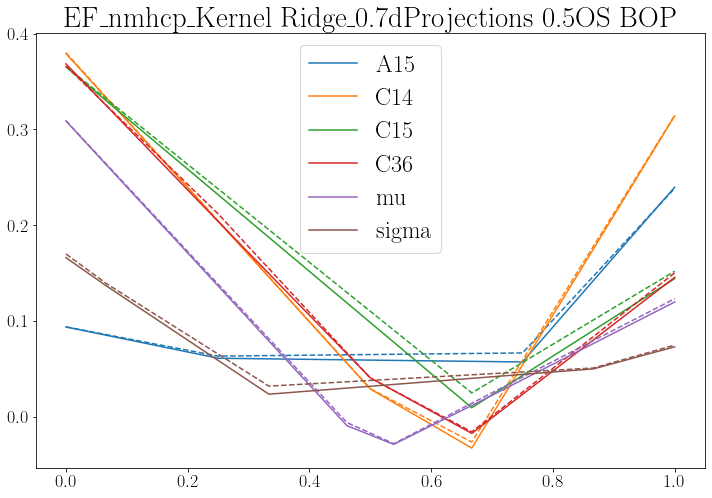

In [60]:
fig, ax = plt.subplots(figsize=(12,8))
for phase, chull in CHULL.items():
    if phase == 'bcc':
        continue
    if phase == 'fcc':
        continue
    if phase == 'hcp':
        continue
    if phase == 'chi':
        continue
    if phase == 'R':
        continue
    bs_phase = BS[BS.Phase == phase]
    prediction_phase_bs = phase_predictionBS[phase]
    vertices = np.unique( chull.simplices[chull.good])
    chull_prediction = PREDICT_CHULL[predicted_target][phase]
    prediction_vertices = np.unique(chull_prediction.vertices[chull_prediction.good])
    xy= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
    xy_prediction = prediction_phase_bs.iloc[vertices][['Fe_pv', predicted_target]].sort_values(by='Fe_pv')
    l=ax.plot(xy['Fe_pv'].values, xy[target_case].values, label = phase)
    ax.plot(xy_prediction['Fe_pv'].values, xy_prediction[predicted_target].values, '--', color=l[0].get_color())
ax.legend()
ax.set_title(predicted_target)

# New Convex Hulls 

In [ ]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
P = Plotting()
points = {}
Prediction_RBS = {}

In [ ]:
from scipy.spatial import ConvexHull

In [ ]:
from matplotlib.lines import Line2D

In [ ]:
from scipy.spatial import QhullError
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    fig_= None,
    ax_ = None,
    components = ['Fe_pv', 'Mo_sv'], 
    palettename = 'tab20c'
):
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        if len(plot_only) == 0:
            plot_only = PhaseBS.keys()
        points = P.get_x_ef_points(PhaseBS, components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if ax_ is None:
            fig_,  ax_ = plt.subplots()#figsize=(12,10)
            handles = []
            labels = []
        else:
            handles, labels = ax_.get_legend_handles_labels()
#        fig = figs_mag[mag]
#        ax = ax_mag[mag]
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                l = ax_.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 1, markersize=2, markeredgecolor='k')
            if plot_points:
                l = ax_.plot(points[phase][components[0]] , points[phase][theproperty], 'o', color = palette[phase], markersize=2)
            handles.append(l[0])
            labels.append(phase)
        leg = ax_.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax_.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax_.set_xlabel(rf'$x_{{{components[0]}}}$')
        fig_.tight_layout()
    return fig_, ax_

In [ ]:
stds = {}
errs = {}
good_vertices = {}

In [ ]:
palette1 = PlottingChulls.make_palette_forlist(['R'])
palette2 = PlottingChulls.make_palette_forlist(['R'], palette_name='gray')
palette3 = PlottingChulls.make_palette_forlist(['R'], palette_name='hls')

In [ ]:
L1 = Line2D([0],[0], marker = 'o', color=palette1['R'], markersize = 1, linewidth = 2)
L2 = Line2D([0],[0], marker = 'o', color=palette2['R'], markersize = 1, linewidth = 2 )
L3 = Line2D([0],[0], marker = 'o', color=palette3['R'], markersize = 1, linewidth = 2 )

In [ ]:
for key, featurename in featurenames.items():
    Prediction_RBS[key] = pd.concat([RBS, Prediction_Values_R[key]], axis = 1)
    points[key] = Prediction_RBS[key][['Fe_pv', target_case]]
    PhasesBS = {'': {'R' : Prediction_RBS[key]}}
    chulls= P.get_convex_hulls(PhasesBS[''], components=['Fe_pv', 'Mo_sv'],
                               viewpoint=[0.5, -10], getproperty=target_case)
    good_vertices[key] = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())
    stds[key] = bag_of_predictions[('Kernel Ridge', key)] .iloc[good_vertices[key]].std(axis=1)
    errs[key] = pd.concat([stds[key], PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds[key].index]], axis = 1 )
    errs[key].rename(columns={0: 'std'}, inplace=True)
    errs[key].sort_values(by='Fe_pv', inplace=True)
    tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=True, fig_ = None, ax_=None)
    e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds[key].index],PhasesBS['']['R'][target_case][stds[key].index],
                 yerr=stds[key], capsize=5, fmt='none', c='k')
    a = tax.fill_between(errs[key]['Fe_pv'], errs[key]['EF_nmhcp']+0.035, errs[key][target_case]-0.035, alpha = 0.2, label='voting test error')
    tfig, tax = plot_chull(OrigPhaseBS,
               target_case,
               mag_list=[''], 
               plot_points=True,
               fig_=tfig,
               ax_=tax, palettename='copper')
    tfig, tax = plot_chull(ValidationPhaseBS,
               target_case,
               mag_list=[''], 
               plot_points=True,
               fig_=tfig,
               ax_=tax,
                           palettename='hls'
                        )
    tax.set_xlabel(r'$x_{Fe}$')
    tax.legend(
        [L1, L2, L3, a, e],
        ['Prediction', 'Training DFT data', 'validation DFT data', 'voting test error', 'std bag of predictions'],
        ncol = 2,
        loc = 'upper right',
        title = f'{ModelName} / {key} '
    )
    tax.set_ylim([-0.1, 0.5])
    file_name = os.path.join(f'Fe-Mo/graphs/R_structure_pred_vs_dft_{ModelName}_{featurename}.pdf')
    tfig.tight_layout()
    tfig.savefig(file_name)

In [ ]:
tfig, tax = plot_chull(OrigPhaseBS,
           target_case,
           mag_list=[''], 
           plot_points=True,
           fig_=None,
           ax_=None, palettename='gray')

tfig, tax = plot_chull(ValidationPhaseBS,
           target_case,
           mag_list=[''], 
           plot_points=True,
           fig_=tfig,
           ax_=tax,
                       palettename='winter'
                    )
palettes = {'ACE': 'summer', '0.7 Projections OS BOP': 'autumn'}
lines = tax.get_lines()
handles = [lines[0], lines[-2]]
labels = ['training data', 'validation data']
#plt.legend(['training data', 'validation data'])

for key, featurename in featurenames.items():
    Prediction_RBS[key] = pd.concat([RBS, Prediction_Values_R[key]], axis = 1)
    points[key] = Prediction_RBS[key][['Fe_pv', target_case]]
    PhasesBS = {'': {'R' : Prediction_RBS[key]}}
    chulls= P.get_convex_hulls(PhasesBS[''], components=['Fe_pv', 'Mo_sv'],
                               viewpoint=[0.5, -10], getproperty=target_case)
    good_vertices[key] = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())
    stds[key] = bag_of_predictions[('Kernel Ridge', key)] .iloc[good_vertices[key]].std(axis=1)
    errs[key] = pd.concat([stds[key], PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds[key].index]], axis = 1 )
    errs[key].rename(columns={0: 'std'}, inplace=True)
    errs[key].sort_values(by='Fe_pv', inplace=True)
    tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=False, fig_ =tfig, ax_=tax, palettename = palettes[key] )
    handles.append(tax.get_lines()[-2])
    labels.append(key)
    this_color = tax.get_lines()[-1].get_color()
    e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds[key].index],PhasesBS['']['R'][target_case][stds[key].index],
                 yerr=stds[key], capsize=5, fmt='none', c=this_color)
tax.set_xlabel(r'$x_{Fe}$')
tax.legend(handles, labels)

# Comparision for the other phases 

In [114]:
def get_bs_byphase(theBS):
    verts = {}
    chulls = {}
    phasepoints = {}
    return {mag: {phase: theBS[(theBS.Phase == phase) & theBS.index.str.contains(mag)] for phase in theBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [ ]:
OrigPhaseBS = get_bs_byphase(BS)

In [ ]:
predictedBS = pd.read_pickle('Fe-Mo/results/Fe-Mo_Kernel Ridge_PredictedBS.pkl')

In [ ]:
predictedBS.columns

In [ ]:
predictedPhaseBS = get_bs_byphase(predictedBS)

In [ ]:
plot_only = ['bcc', 'C14', 'sigma', 'mu', 'C36', 'A15', 'hcp']

In [ ]:
palettename = 'Dark2'

In [ ]:
ModelName

In [ ]:
for featurename in featurenames:
    fig, ax = plot_chull(
        predictedPhaseBS, theproperty='EF_nmhcp', mag_list=[''], 
               components= [ 'Fe_pv', 'Mo'], plot_points = False,
        plot_only=plot_only, palettename=palettename
    )

    fig, ax = plot_chull(
        predictedPhaseBS, theproperty=f'EF_nmhcp_{featurename}', mag_list=[''], 
               components= [ 'Fe_pv', 'Mo'], plot_points = False,
        plot_only=plot_only, palettename=palettename, line_styles = '--o', fig_ = fig, ax_ = ax
    )

    ax.set_ylim([-0.1, 0.5])
    palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
    L = []
    label = []
    for name, color in palette.items():
        L.append(Line2D([0], [0], color = color, lw = 1))
        label.append(name)
    L.append(Line2D([0, 1],[0, 0], linestyle = '--', marker = 'o', color='k', linewidth=1, markersize=2))
    label.append('prediction')
    leg = ax.legend(L, label, loc = 'upper right', ncol =2, scatterpoints=2,  title=f'{ModelName}/{featurename}')
    ax.set_xlabel(r'$x_{Fe}$')
    modelforfile=ModelName.replace(' ', '')
    featureforfile=featurename.replace(' ', '')
    fig.tight_layout()
    file_name =os.path.join(dataset, 'graphs', f'{dataset}_CompareCHull_{modelforfile}_{featureforfile}.pdf')
    fig.savefig(file_name)

In [ ]:
fig, axes = plt.subplots(2,2, sharex = True, sharey = True)
predictedBS.plot.scatter(x='EF_nmhcp_ACE', y= 'EF_nmhcp_0.7 Projections OS BOP', ax = axes[1,1])
rmse = np.sqrt(((predictedBS['EF_nmhcp_ACE'] - predictedBS['EF_nmhcp_0.7 Projections OS BOP'])**2).sum()/len(predictedBS))
axes[1,1].legend(title=f'RMSE = {rmse*1000:5.2f}')
predictedBS.plot.scatter(x='EF_nmhcp', y='EF_nmhcp_0.7 Projections OS BOP' , ax = axes[1,0])
rmse = np.sqrt(((predictedBS['EF_nmhcp'] - predictedBS['EF_nmhcp_0.7 Projections OS BOP'])**2).sum()/len(predictedBS))
axes[1,0].legend(title=f'RMSE = {rmse*1000:5.2f}')
predictedBS.plot.scatter(x='EF_nmhcp', y='EF_nmhcp_ACE' , ax = axes[0,0])
rmse = np.sqrt(((predictedBS['EF_nmhcp'] - predictedBS['EF_nmhcp_ACE'])**2).sum()/len(predictedBS))
fig.subplots_adjust(wspace = 0.05, hspace=0.05)
axes[0,0].legend(title=f'RMSE = {rmse*1000:5.2f}')

In [ ]:
predictedBS[['EF_nmhcp']]

#figsize CH  for DFT calculations full

In [ ]:
plot_only = plot_only + ['R']

In [ ]:
palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)

In [ ]:
fig, ax = plt.subplots(figsize=(14,9))
fig, ax = plot_chull(
    OrigPhaseBS, theproperty='EF_nmhcp', mag_list=[''], palettename='Dark2', 
    plot_only=plot_only, fig_=fig, ax_ = ax
)
lines = []
labels = []
for name, color in palette.items():
    lines.append(Line2D([0],[0],linewidth = 5, color=color))
    labels.append(name)
ax.legend(lines, labels)
ax.set_xlabel(r'$x_{Fe}$')
filename = os.path.join(dataset, 'graphs', f'{dataset}_ConvexHulls.pdf')
fig.savefig(filename)

In [ ]:
OrigPhaseBS['']['C36']

# Bopxplots 

In [ ]:
equals = RBS.index.intersection(calcs_R.index)

In [ ]:
alldata = pd.concat([RBS['Fe_pv'] , bag_of_predictions], axis = 1).loc[equals]

In [ ]:
melted = alldata.melt(id_vars='Fe_pv')

In [ ]:
sns.boxplot(data=melted, x= 'Fe_pv', y = 'value')

In [ ]:
alldata = alldata.loc[equals].melt(id_vars=['Fe_pv'])

In [ ]:
sns.scatterplot(alldata

In [ ]:
ax = sns.scatterplot(x = RBS['Fe_pv'][equals], y = Prediction[equals], label = 'Prediction for R')
sns.scatterplot(data = calcs_R, x = 'Fe_pv', y = 'EF_nmhcp', ax = ax, ls='--', err=ERR[equals])
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [ ]:
ax = sns.scatterplot()